In [1]:

import sys, os
project_root = r"D:\DevMentor AI"
if os.getcwd() != project_root:
    os.chdir(project_root)
sys.path.insert(0, project_root)
print("Working directory:", os.getcwd())

Working directory: D:\DevMentor AI


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from sklearn.pipeline import make_pipeline
import seaborn as sns
import joblib

from client.runner import get_output_error, parse_error
from sanitizer.sanitizer import sanitize

print("Imports successful")

Imports successful


## What TF-IDF Does

TF-IDF scores each word in an error message by how useful it is for 
telling categories apart. A word that shows up in almost every error 
(like "error" or "line") gets a low score, since it doesn't help 
distinguish one category from another. A word that's rare but specific 
to certain errors (like "subscriptable" or "iterable") gets a high 
score, since seeing it strongly suggests a particular category. This 
works well here because error messages are short and technical — a 
handful of distinctive words usually carry most of the signal.

In [3]:
def make_row(code_snippet: str, label: str) -> dict:
    """Runs a code snippet, captures its error type and message, sanitizes
    the message, and returns a dataset row combining both. Returns None
    if the snippet didn't error."""
    import subprocess
    result = subprocess.run(
        [sys.executable, "-c", code_snippet],
        capture_output=True, text=True
    )
    if result.returncode == 0:
        return None
    parsed = parse_error(result.stderr)
    if not parsed:
        return None
    error_type, message = parsed
    sanitized_message = sanitize(message)
    return {"text": f"{error_type} {sanitized_message}", "label": label}


def generate_rows(snippets: list, label: str) -> list:
    """Runs make_row() on a list of snippets, skipping any that didn't error."""
    rows = []
    for s in snippets:
        row = make_row(s, label)
        if row:
            rows.append(row)
    return rows

In [4]:
key_error_snippets = [
    'user = {"name": "apurv"}; print(user["email"])',
    'config = {"debug": True}; print(config["timeout"])',
    'data = {"id": 1, "name": "test"}; print(data["value"])',
    'settings = {"theme": "dark"}; print(settings["language"])',
    'response = {"status": 200}; print(response["body"])',
    'cache = {}; print(cache["missing_key"])',
    'headers = {"Content-Type": "json"}; print(headers["Authorization"])',
    'params = {"page": 1}; print(params["limit"])',
    'record = {"id": 5}; print(record["timestamp"])',
    'payload = {"user_id": 42}; print(payload["session_token"])',
    'options = {"verbose": False}; print(options["quiet"])',
    'metadata = {"version": "1.0"}; print(metadata["build"])',
]

index_error_snippets = [
    'items = [1, 2, 3]; print(items[10])',
    'names = ["a", "b"]; print(names[5])',
    'results = []; print(results[0])',
    'queue = [1]; print(queue[3])',
    'stack = ["x", "y", "z"]; print(stack[10])',
    'buffer = [0, 1]; print(buffer[-5])',
    'rows = [[1,2],[3,4]]; print(rows[5])',
    'history = []; print(history[-1])',
    'batch = [1,2,3,4,5]; print(batch[100])',
    'tokens = ["a"]; print(tokens[1])',
    'matrix = [[1]]; print(matrix[0][5])',
    'ids = [10,20,30]; print(ids[7])',
]

# Combinatorial generation for type_error: pair different Python types with operations that don't work between them, to produce many genuinely distinct messages.
_type_pairs = [
    ("5", "'text'"),
    ("'hello'", "10"),
    ("[1,2]", "'a'"),
    ("{}", "{}"),
    ("True", "'yes'"),
    ("3.5", "'x'"),
    ("(1,2)", "'a'"),
    ("{1,2}", "'a'"),
    ("5", "None"),
    ("'x'", "5.5"),
    ("[1]", "{1:2}"),
    ("(1,)", "[1]"),
]

type_error_snippets = []
for a, b in _type_pairs:
    type_error_snippets.append(f"x = {a} + {b}")

type_error_snippets += [
    'val = len(5)',
    'name = "test"; name()',
    'count = 10; count["key"]',
    'value = 3.14; value["key"]',
    'flag = True; flag[0]',
    'num = 5; num()',
    'x = 5 - "a"',
    'x = "a" * [1]',
    'x = [1,2] - [1]',
    'x = 5 / "a"',
]

none_type_error_snippets = [
    'x = None; print(x.upper())',
    'data = None; print(data["key"])',
    'result = None; print(len(result))',
    'user = None; print(user.name)',
    'response = None; print(response["status"])',
    'value = None; print(value + 5)',
    'obj = None; obj.method()',
    'items = None; print(items[0])',
    'config = None; print(config.get("key"))',
    'total = None; print(total * 2)',
    'record = None; print(record.id)',
    'output = None; print(output.append(1))',
]

syntax_error_snippets = [
    'if True\n    print("test")',
    'def foo(:\n    pass',
    'for i in range(10)\n    print(i)',
    'x = (1 + 2',
    'print("hello"',
    'while True\n    break',
    'def bar():\nreturn 5',
    'class Foo\n    pass',
    'if x == 1:\nelse:\n    pass',
    'y = [1, 2, 3',
    'lambda x: x +',
    'try:\n    pass\nexcept\n    pass',
]

_types_and_methods = [
    ("5", "append"),
    ("'text'", "push"),
    ("[1,2]", "get"),
    ("10", "upper"),
    ('{"a": 1}', "append"),
    ("3.14", "split"),
    ("True", "lower"),
    ("'hello'", "add"),
    ("[1,2]", "keys"),
    ("5", "strip"),
    ("(1,2)", "append"),
    ("{1,2}", "index"),
    ("5.5", "encode"),
    ("False", "items"),
    ("(1,)", "pop"),
    ("{1:2}", "sort"),
    ("'x'", "extend"),
    ("[1]", "update"),
]

attribute_error_snippets = []
for obj, method in _types_and_methods:
    attribute_error_snippets.append(f"x = {obj}; x.{method}()")

attribute_error_snippets.append('obj = object(); obj.missing_method()')

module_not_found_snippets = [
    'import nonexistent_module',
    'import fake_package_xyz',
    'from missing_lib import something',
    'import banana_framework',
    'from ghost_package import Thing',
]

file_not_found_snippets = [
    'open("missing_file.txt")',
    'open("does_not_exist.csv")',
    'open("/nonexistent/path/file.txt")',
    'open("no_such_report.pdf")',
    'open("phantom_script.py")',
]

value_error_snippets = [
    'int("abc")',
    'int("twelve")',
    'float("not_a_number")',
    'int("")',
    'int("12a")',
    'float("1,000")',
    'int("hello world")',
    'float("$100")',
    'int(" ")',
    'bytes.fromhex("xyz")',
    'int("3.14")',
    'int("--5")',
    'float("1e")',
    '[1,2,3].index(9)',
    'list("abc").remove("z")',
    'int("5", base=37)',
    'float("inf_")',
]

network_error_snippets = [
    'import requests; requests.get("http://127.0.0.1:1", timeout=1)',
    'import requests; requests.get("http://127.0.0.1:2", timeout=1)',
    'import requests; requests.get("http://localhost:9999", timeout=1)',
    'import requests; requests.get("http://127.0.0.1:3", timeout=1)',
    'import requests; requests.get("http://192.0.2.1:80", timeout=1)',
]

permission_error_snippets = [
    'open("readonly.txt", "a")',
    'open("readonly.txt", "w")',
    'open("readonly.txt", "r+")',
]

_other_errors = [
    ("ArithmeticError", "Something went wrong mathematically"),
    ("LookupError", "Could not find the requested item"),
    ("RuntimeError", "Failed to initialize the connection pool"),
    ("RuntimeError", "Unexpected state reached during processing"),
    ("NotImplementedError", "This feature is not yet supported"),
    ("NotImplementedError", "This feature is not built yet"),
    ("OverflowError", "Result too large to represent"),
    ("StopIteration", "No more items to iterate"),
    ("BufferError", "Buffer operation could not be performed"),
    ("EOFError", "Unexpected end of input"),
    ("ZeroDivisionError", "division by zero"),
    ("ImportError", "cannot import name \\'missing_func\\' from \\'some_module\\'"),
    ("RecursionError", "maximum recursion depth exceeded"),
    ("ReferenceError", "weakly-referenced object no longer exists"),
    ("SystemError", "unexpected internal error occurred"),
    ("UnboundLocalError", "local variable \\'x\\' referenced before assignment"),
    ("FloatingPointError", "floating point operation failed"),
    ("IndentationError", "unexpected indent"),
    ("TabError", "inconsistent use of tabs and spaces in indentation"),
]

other_error_snippets = [f'raise {exc}("{msg}")' for exc, msg in _other_errors]

print("All snippet lists loaded")
print(f"type_error: {len(type_error_snippets)}, attribute_error: {len(attribute_error_snippets)}, "
      f"value_error: {len(value_error_snippets)}, other_error: {len(other_error_snippets)}")

All snippet lists loaded
type_error: 22, attribute_error: 19, value_error: 17, other_error: 19


In [5]:
key_error_rows = generate_rows(key_error_snippets, "key_error")
index_error_rows = generate_rows(index_error_snippets, "index_error")
type_error_rows = generate_rows(type_error_snippets, "type_error")
none_type_error_rows = generate_rows(none_type_error_snippets, "none_type_error")
syntax_error_rows = generate_rows(syntax_error_snippets, "syntax_error")
attribute_error_rows = generate_rows(attribute_error_snippets, "attribute_error")
module_not_found_rows = generate_rows(module_not_found_snippets, "module_not_found")
file_not_found_rows = generate_rows(file_not_found_snippets, "file_not_found")
value_error_rows = generate_rows(value_error_snippets, "value_error")
network_error_rows = generate_rows(network_error_snippets, "network_error")
permission_error_rows = generate_rows(permission_error_snippets, "permission_error")
other_error_rows = generate_rows(other_error_snippets, "other_error")

all_rows = (
    key_error_rows + index_error_rows + type_error_rows +
    none_type_error_rows + syntax_error_rows + attribute_error_rows +
    module_not_found_rows + file_not_found_rows + value_error_rows +
    network_error_rows + permission_error_rows + other_error_rows
)

df = pd.DataFrame(all_rows)
print("Total rows before trim:", df.shape)
print(df["label"].value_counts())

Total rows before trim: (143, 2)
label
type_error          22
attribute_error     19
other_error         19
value_error         17
key_error           12
index_error         12
none_type_error     12
syntax_error        12
module_not_found     5
file_not_found       5
network_error        5
permission_error     3
Name: count, dtype: int64


In [6]:
df = df.groupby(["text", "label"]).head(3).reset_index(drop=True)
df.to_csv("ml_engine/data/labeled/dataset.csv", index=False)
print("Saved:", df.shape)
print(df["label"].value_counts())

Saved: (132, 2)
label
type_error          22
attribute_error     19
other_error         19
value_error         17
key_error           12
none_type_error     12
syntax_error        10
module_not_found     5
file_not_found       5
network_error        5
index_error          3
permission_error     3
Name: count, dtype: int64


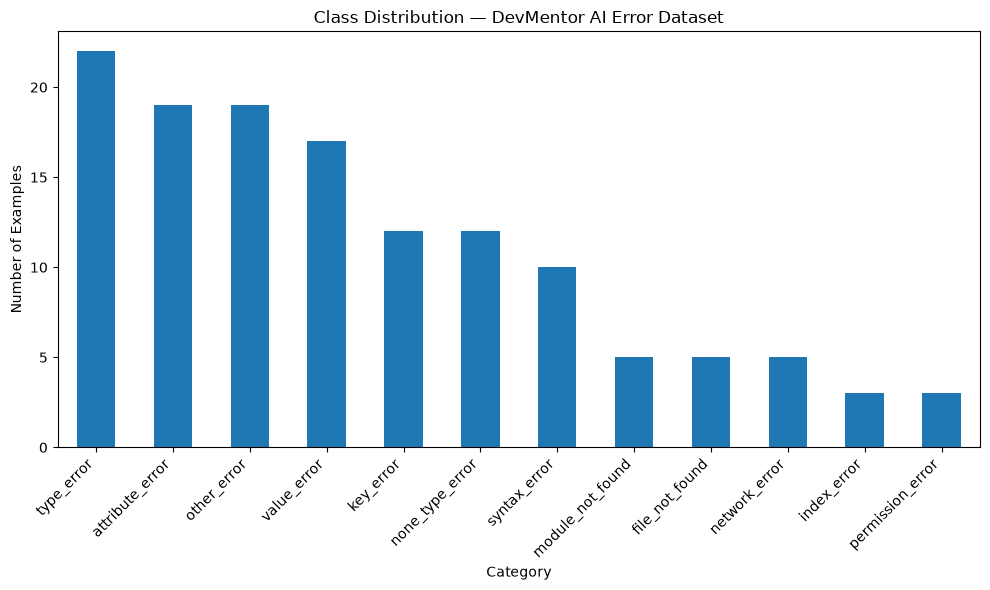

In [7]:
plt.figure(figsize=(10, 6))
df["label"].value_counts().plot(kind="bar")
plt.title("Class Distribution — DevMentor AI Error Dataset")
plt.xlabel("Category")
plt.ylabel("Number of Examples")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("ml_engine/models/class_distribution.png")
plt.show()

## Dataset Notes

**Size (132 rows vs. original 500+ target):** Started at 102 rows after 
finding duplicate examples add no TF-IDF signal once a category's real 
message diversity is exhausted (index_error, syntax_error, 
permission_error all plateau quickly). Expanded type_error, 
attribute_error, other_error, and value_error combinatorially 
(pairing types with operations, exception classes with messages), 
since those categories have real underlying diversity. index_error and 
permission_error stay small deliberately — their messages are 
genuinely fixed by Python's implementation, more examples would only 
be duplicates.

**Evaluation method:** 3-fold stratified cross-validation is used 
instead of a held-out test split. A true 80/10/10 split was tested 
directly: the 11-row final test set covered only 7 of 12 categories, 
leaving 5 categories completely untested. 3-fold CV evaluates every 
row exactly once while still never training and testing on the same 
example, which is the honest choice for a dataset this size.

In [8]:
X = df["text"]
y = df["label"]

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Linear SVM": LinearSVC(max_iter=2000),
    "Multinomial NB": MultinomialNB(),
    "Linear SVM (calibrated)": CalibratedClassifierCV(LinearSVC(max_iter=2000), cv=2),
}

results = {}
for name, model in models.items():
    pipeline = make_pipeline(TfidfVectorizer(max_features=5000, ngram_range=(1, 2)), model)
    y_pred = cross_val_predict(pipeline, X, y, cv=cv)
    macro_f1 = f1_score(y, y_pred, average="macro", zero_division=0)
    results[name] = {"macro_f1": round(macro_f1, 3), "predictions": y_pred}
    print(f"{name}: macro F1 = {macro_f1:.3f}")

Logistic Regression: macro F1 = 0.801
Linear SVM: macro F1 = 0.957
Multinomial NB: macro F1 = 0.661
Linear SVM (calibrated): macro F1 = 0.931


## Model Comparison and Decision

All four evaluated with 3-fold stratified cross-validation on the full 
132-row dataset (error_type included in the training text).

| Model | Macro F1 |
|---|---|
| Logistic Regression | 0.801 |
| Linear SVM | 0.957 |
| Multinomial Naive Bayes | 0.661 |
| Linear SVM (calibrated) | 0.931 |

Logistic Regression was the original choice, based on an earlier, 
smaller dataset where it and Linear SVM scored within a point of each 
other. After expanding type_error, attribute_error, other_error, and 
value_error combinatorially, the gap widened sharply: Logistic 
Regression's probability-based boundary proved far more sensitive to 
the resulting class imbalance, losing most on the thinnest categories 
(index_error 0.50, permission_error 0.50, none_type_error 0.38) even 
though those categories' own data never changed. Linear SVM's 
margin-based boundary held up much better under the same shift.

Calibrating Linear SVM with CalibratedClassifierCV costs 2.6 points 
of macro F1 (0.957 to 0.931), the expected trade-off for converting 
decision scores into genuine probabilities. CalibratedClassifierCV's 
internal cv was set to 2 rather than the default, since several 
classes (index_error, permission_error) have only 3 total examples and 
cannot support a nested 3-fold split on top of the outer evaluation fold.

**Decision: Linear SVM, calibrated (cv=2).** It outperforms Logistic 
Regression by a wide margin even after calibration, and calibration 
gives it the predict_proba output that future confidence-threshold 
routing needs — the same requirement that drove the original LR 
choice, now met by the actually-better model instead of as a 
substitute for it.

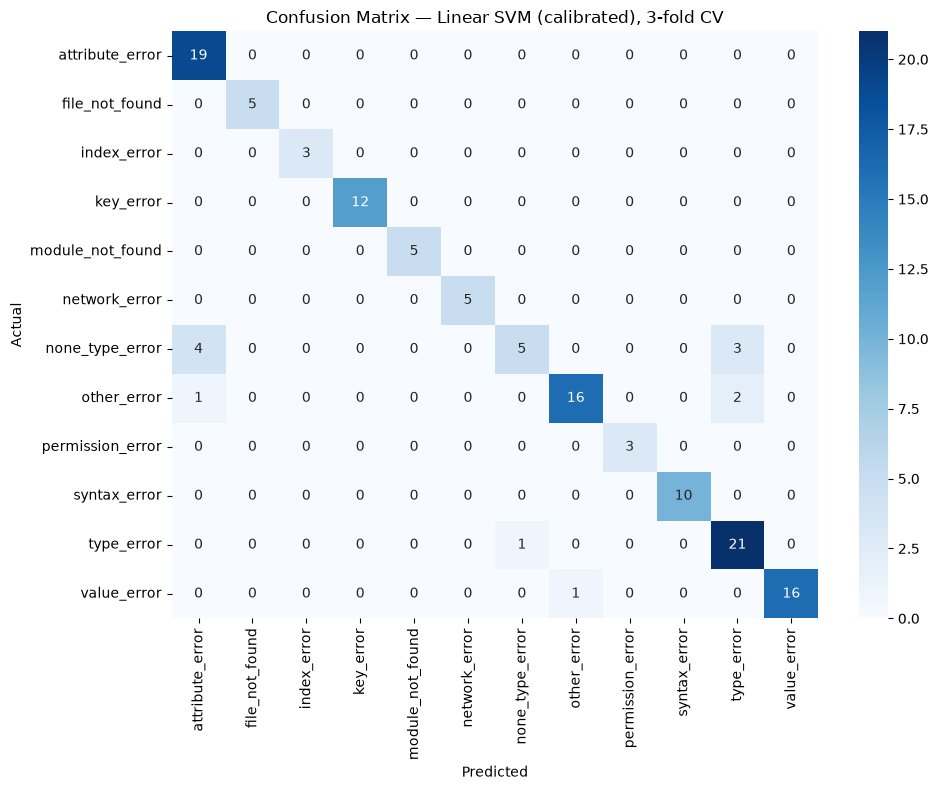

In [9]:
final_pipeline = make_pipeline(
    TfidfVectorizer(max_features=5000, ngram_range=(1, 2)),
    CalibratedClassifierCV(LinearSVC(max_iter=2000), cv=2),
)
y_pred_final = results["Linear SVM (calibrated)"]["predictions"]

labels = sorted(y.unique())
cm = confusion_matrix(y, y_pred_final, labels=labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Linear SVM (calibrated), 3-fold CV")
plt.tight_layout()
plt.savefig("ml_engine/models/confusion_matrix_lr.png")
plt.show()

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

clf_final = CalibratedClassifierCV(LinearSVC(max_iter=2000), cv=2)
clf_final.fit(X_train_vec, y_train)

y_pred_final_split = clf_final.predict(X_test_vec)
print(classification_report(y_test, y_pred_final_split, zero_division=0))

joblib.dump(vectorizer, "ml_engine/models/vectorizer.joblib")
joblib.dump(clf_final, "ml_engine/models/classifier.joblib")
print("Saved vectorizer.joblib and classifier.joblib")

                  precision    recall  f1-score   support

 attribute_error       1.00      1.00      1.00         4
  file_not_found       1.00      1.00      1.00         1
     index_error       1.00      1.00      1.00         1
       key_error       1.00      1.00      1.00         2
module_not_found       1.00      1.00      1.00         1
   network_error       1.00      1.00      1.00         1
 none_type_error       0.50      0.50      0.50         2
     other_error       1.00      1.00      1.00         4
permission_error       1.00      1.00      1.00         1
    syntax_error       1.00      1.00      1.00         2
      type_error       0.80      0.80      0.80         5
     value_error       1.00      1.00      1.00         3

        accuracy                           0.93        27
       macro avg       0.94      0.94      0.94        27
    weighted avg       0.93      0.93      0.93        27

Saved vectorizer.joblib and classifier.joblib
